Bayesian inference to identify crystalline structures for XRD by Murakami et. al.

In [1]:
import copy
import numpy as np
from dataclasses import dataclass
from scipy.special import gammaln
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import xml.etree.ElementTree as ET
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

#import numpy as np

$(p_m^{(k)}, I_{m}^{(k)})$ = diffraction peak angle (peak position) $^{\circ}$ and relative intensity of the $m$-th diffraciton peak in $F_k$ for a crystal structure $k$.

First, we want to take all of the XRD patterns that we want to compare the observed pattern.

1. CIF files

In [2]:
'''from mp_api.client import MPRester

# Your provided Materials Project API key
api_key = "Adj7gfNJiIdpiy7erTpTZmPdjgGrD14b"

material_id = "mp-1001117"

with MPRester(api_key) as mpr:
    # Fetch the structure object from the database
    structure = mpr.get_structure_by_material_id(material_id)
    
    # Export and save the structure to your current folder as a CIF file
    structure.to(filename=f"{material_id}.cif", fmt="cif")

print(f"Successfully downloaded {material_id}.cif!")'''

'from mp_api.client import MPRester\n\n# Your provided Materials Project API key\napi_key = "Adj7gfNJiIdpiy7erTpTZmPdjgGrD14b"\n\nmaterial_id = "mp-1001117"\n\nwith MPRester(api_key) as mpr:\n    # Fetch the structure object from the database\n    structure = mpr.get_structure_by_material_id(material_id)\n\n    # Export and save the structure to your current folder as a CIF file\n    structure.to(filename=f"{material_id}.cif", fmt="cif")\n\nprint(f"Successfully downloaded {material_id}.cif!")'

2. Normalized Stick patterns

In [3]:


def get_xrd_peaks(cif_file_path, radiation="CuKa", two_theta_range=(30.02743856,90.0000048)):
    """
    Reads a CIF file and returns the 2-theta values and normalized intensities
    for its XRD stick pattern.
    
    Parameters:
    - cif_file_path (str): Path to the input .cif file.
    - radiation (str): X-ray radiation source (default is 'CuKa').
    - two_theta_range (tuple): The minimum and maximum 2-theta angles to consider.
    
    Returns:
    - two_thetas (list of float): The 2-theta angles of the peaks.
    - intensities (list of float): The corresponding normalized intensities (scaled 0 to 1).
    """
    
    # 1. Load the crystal structure from the CIF file
    try:
        structure = Structure.from_file(cif_file_path)
    except Exception as e:
        print(f"Error reading CIF file: {e}")
        return None, None

    # 2. Initialize the XRD calculator
    calculator = XRDCalculator(wavelength=radiation)
    
    # 3. Calculate the diffraction pattern
    pattern = calculator.get_pattern(structure, two_theta_range=two_theta_range)
    
    # 4. Extract and format the data
    # pattern.x contains the 2-theta values as a numpy array; convert to a standard Python list
    two_thetas = pattern.x.tolist()
    
    # pattern.y contains intensities with the max peak at 100. Normalize to a 0-1 scale.
    intensities = [i / 100.0 for i in pattern.y]

    return two_thetas, intensities



If this doesn't work, then the .ipynb file probably cannot find the path to the file in the directory

In [4]:
angles_Mn4N_ferro, peaks_Mn4N_ferro = get_xrd_peaks("mp-505622.cif")
angles_Mn4N_ferri, peaks_Mn4N_ferri = get_xrd_peaks("mp-637576.cif")
angles_Mn3N2_tetragonal, peaks_Mn3N2_tetragonal = get_xrd_peaks("mp-12857.cif")
angles_Mn3N2_trigonal, peaks_Mn3N2_trigonal = get_xrd_peaks("mp-1001117.cif")
angles_mp_1000, peaks_mp_1000 = get_xrd_peaks("mp-1000.cif")
angles_mp_6930, peaks_mp_6930 = get_xrd_peaks("mp-6930.cif")
angles_mp_7000, peaks_mp_7000 = get_xrd_peaks("mp-7000.cif")
angles_mp_7029, peaks_mp_7029 = get_xrd_peaks("mp-7029.cif")
angles_mp_10064, peaks_mp_10064 = get_xrd_peaks("mp-10064.cif")

c:\Users\Owner\AppData\Local\Programs\Python\Python312\Lib\site-packages\pymatgen\core\structure.py:3117: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [5]:
import numpy as np

k, m = 9, len(angles_mp_1000)

p = [angles_Mn4N_ferro, angles_Mn4N_ferri, angles_Mn3N2_tetragonal, angles_Mn3N2_trigonal, angles_mp_1000, angles_mp_6930, angles_mp_7000, angles_mp_7029, angles_mp_10064]
I = [peaks_Mn4N_ferro, peaks_Mn4N_ferri, peaks_Mn3N2_tetragonal, peaks_Mn3N2_trigonal, peaks_mp_1000, peaks_mp_6930, peaks_mp_7000, peaks_mp_7029, peaks_mp_10064]
labels = ["Mn4N_ferro", "Mn4N_ferri", "Mn3N2_tetragonal", "Mn3N2_trigonal", "mp_1000", "mp_6930", "mp_7000", "mp_7029", "mp_10064"]
M = [len(p_i) for p_i in p]

# 1. Find the max length
max_p = max(len(p_i) for p_i in p)

# 2. Pad each vector with zeros
p = np.array([
    np.pad(p_i, (0, max_p - len(p_i)), mode='constant') 
    for p_i in p
])

max_I = max(len(I_i) for I_i in I)

# 2. Pad each vector with zeros
I = np.array([
    np.pad(I_i, (0, max_I - len(I_i)), mode='constant') 
    for I_i in I
])

The set of all observation data points in the graph is $D= \{(x_i,y_i)\}$.
This is the observed XRD pattern. So, now we need the observed XRD pattern.

In [6]:
# 1. Load the repaired XML file
tree = ET.parse('Mn4N_4pct_N2_[PIX]_GIXRD_30-90_0p1_0p1dps_15reps_3hrs.xrdml')
root = tree.getroot()

# The namespace PANalytical uses
ns = {'xrd': 'http://www.xrdml.com/XRDMeasurement/2.1'}

# 2. Extract the 2-Theta X values (Start and End)
pos = root.find('.//xrd:positions[@axis="2Theta"]', ns)
start_x = float(pos.find('xrd:startPosition', ns).text)
end_x = float(pos.find('xrd:endPosition', ns).text)

# 3. Extract the counts (Y values)
# Note: Your file is a "Repeated scan" with multiple <scan> blocks. 
# This gathers all scans and sums their intensities.
y_data = []
for counts in root.findall('.//xrd:counts', ns):
    # Convert space-separated string of numbers into a numpy array
    scan_y = np.fromstring(counts.text, sep=' ')
    y_data.append(scan_y)

# Sum all the repeated scans together
y = np.sum(y_data, axis=0)

# 4. Generate the X array based on the start/end positions and the number of Y points
x = np.linspace(start_x, end_x, len(y))

print("Data loaded successfully!")
print(f"x_i (2-Theta) array size: {len(x)}")
print(f"y_i (Intensity) array size: {len(y)}")

Data loaded successfully!
x_i (2-Theta) array size: 610
y_i (Intensity) array size: 610


Prior Distributions over all parameters following a certain order

Gamma distribution: [$h_k, \alpha_k, u_k, v_k, w_k, s_k, t_k, a, \sigma_{bg}$]

In [7]:
y_min = np.min(y)
y_max = np.max(y)
# Create the generator instance
rng = np.random.default_rng()

uniform_samples = rng.uniform(low=0.0, high=1.0, size=(5, 1000))
# Variables with different shape parameters (k)
shapes = [4.0, 5.0, 1.0, 1.0, 2.0, 2.0, 1.0, 2.0, 2.0]
# variables with different scale parameters (theta)
scales = [((y_max-y_min)/4), 0.25, 0.10, 0.10, 0.05, 0.05, 0.10, y_max, 2.50]

# You can pass the list of shapes directly if the size matches
gamma_samples = rng.gamma(shape=shapes, scale=scales, size=((9,9)))
h = gamma_samples[0]
alpha = gamma_samples[1]
u = gamma_samples[2]
v = gamma_samples[3]
w = gamma_samples[4]
s = gamma_samples[5]
t = gamma_samples[6]
a = gamma_samples[7]
sigma_bg = gamma_samples[8]

In [8]:
t.shape

(9,)

Uniform distribution: [$r_k, r_{bg}, b$]

In [9]:
lows = [0.00, 0.00, y_min-np.sqrt(y_min)/2]
highs = [1.00, 1.00, y_min+np.sqrt(y_min)/2]

uniform_samples = rng.uniform(low=lows, high=highs, size=(9,3))
r = uniform_samples[:,0]
r_bg = uniform_samples[:,1]
b = uniform_samples[:,2]

Normal distribution; [$\mu_k$]

$g_k (k = 1, \cdots, K) $

In [10]:
# = 0.5       # Probability of success (1)
size = 9     # Number of samples
# Generate Bernoulli random variables (0 or 1)
g = rng.binomial(n=1, p=0.5, size=size)
mu = rng.normal(loc=0.00, scale=0.05, size=size)

Log-Priors

$r_k$ = Gauss-Lorentz ratio of the peak of crystal structure k

$\rho_{mk}$ = peak position of the peak function

$G(x_i)$ = Gaussian function

$L(x_i)$ = Lorentzian function

$V(x_i;\rho_{mk}, \Sigma_k, \Omega_k, r_k)$  = Pseudo-Voigt function

$C_{F_k}(x_i; \Theta_s^{k})$ = profile function of the candidate crystal structure $k$

In [11]:
EPS = 1e-12 # used for clipping small values of y
def pseudo_voigt_matrix(x_deg, rho_deg, alpha_k, r_k, u_k, v_k, w_k, s_k, t_k):
    x_deg = np.asarray(x_deg, dtype=float)
    rho_deg = np.asarray(rho_deg, dtype=float)

    theta = np.deg2rad(x_deg / 2.0)[:, None]   # for tan/sec only
    dx = x_deg[:, None] - rho_deg[None, :]     # keep widths in degree units

    # Murakami asymmetry factor
    A = np.where(x_deg[:, None] >= rho_deg[None, :], alpha_k, 1.0)

    sigma = A * np.sqrt(np.clip(u_k * np.tan(theta) ** 2
                                - v_k * np.tan(theta)
                                + w_k, EPS, None))

    omega = A * np.clip(s_k * (1.0 / np.cos(theta))
                        + t_k * np.tan(theta), EPS, None)

    gauss = (2.0 / sigma) * np.sqrt(np.log(2.0) / np.pi) \
            * np.exp(-np.log(2.0) * (2.0 * dx / sigma) ** 2)

    lorentz = (2.0 / (np.pi * omega)) \
              * 1.0 / (1.0 + (2.0 * dx / omega) ** 2)

    return (1.0 - r_k) * gauss + r_k * lorentz


def phase_profile(x_deg, I_k, p_k, M_k, mu_k, alpha_k, r_k, u_k, v_k, w_k, s_k, t_k):
    """
    C_Fk(x_i, Θ_S^(k))
    """
    p_k = np.asarray(p_k[:M_k], dtype=float)
    I_k = np.asarray(I_k[:M_k], dtype=float)
    rho_deg = p_k + mu_k

    V = pseudo_voigt_matrix(
        x_deg=x_deg,
        rho_deg=rho_deg,
        alpha_k=alpha_k,
        r_k=r_k,
        u_k=u_k,
        v_k=v_k,
        w_k=w_k,
        s_k=s_k,
        t_k=t_k,
    )
    return V @ I_k


def background_profile(x_deg, sigma_bg, r_bg, a, b):
    sigma_bg = max(float(sigma_bg), EPS)
    r_bg = float(r_bg)

    dx = np.asarray(x_deg, dtype=float)
    gauss = (2.0 / sigma_bg) * np.sqrt(np.log(2.0) / np.pi) \
            * np.exp(-np.log(2.0) * (2.0 * dx / sigma_bg) ** 2)

    lorentz = (2.0 / (np.pi * sigma_bg)) \
              * 1.0 / (1.0 + (2.0 * dx / sigma_bg) ** 2)

    return a * ((1.0 - r_bg) * gauss + r_bg * lorentz) + b

Markov-Chain-Monte-Carlo (MCMC)

In [12]:
EPS = 1e-12


@dataclass
class State:
    g: np.ndarray      # shape (K,), binary phase indicators
    h: np.ndarray      # shape (K,), phase intensities
    mu: np.ndarray     # shape (K,), peak shifts
    alpha: np.ndarray  # shape (K,), asymmetry parameters
    r: np.ndarray      # shape (K,), Lorentz-Gauss mix for each phase
    u: np.ndarray      # shape (K,), Gaussian width param
    v: np.ndarray      # shape (K,), Gaussian width param
    w: np.ndarray      # shape (K,), Gaussian width param
    s: np.ndarray      # shape (K,), Lorentz width param
    t: np.ndarray      # shape (K,), Lorentz width param
    sigma_bg: float    # scalar background width
    r_bg: float        # scalar background Lorentz-Gauss mix
    a: float           # scalar background amplitude
    b: float           # scalar background baseline


def log_gamma(x, shape, scale):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0.0):
        return -np.inf
    return np.sum((shape - 1.0) * np.log(x) - x / scale - shape * np.log(scale) - gammaln(shape))


def log_normal(x, mean, sd):
    x = np.asarray(x, dtype=float)
    var = sd ** 2
    return np.sum(-0.5 * np.log(2.0 * np.pi * var) - 0.5 * ((x - mean) ** 2) / var)


def log_uniform_box(x, lo, hi):
    x = np.asarray(x, dtype=float)
    if np.any(x < lo) or np.any(x > hi):
        return -np.inf
    # constant inside support; keeping 0 is enough for MH
    return 0.0


def log_bernoulli(x, p):
    x = np.asarray(x, dtype=int)
    if np.any((x != 0) & (x != 1)):
        return -np.inf
    return np.sum(x * np.log(p) + (1 - x) * np.log(1 - p))


def log_prior(state: State, y_min: float, y_max: float, p_g: float = 0.5) -> float:
    """
    Priors based on the Murakami prior section for Θ parameters.
    g_k ~ Bernoulli(0.5).
    """
    b_halfspan = np.sqrt(max(y_min, 1.0)) / 2.0
    h_scale = max((y_max - y_min) / 4.0, EPS)

    lp = 0.0
    lp += log_bernoulli(state.g, p_g)

    # Murakami priors for profile parameters
    lp += log_gamma(state.h,     shape=4.0, scale=h_scale)
    lp += log_normal(state.mu,   mean=0.0,  sd=0.05)
    lp += log_gamma(state.alpha, shape=5.0, scale=0.25)
    lp += log_uniform_box(state.r, lo=0.0, hi=1.0)
    lp += log_gamma(state.u,     shape=1.0, scale=0.10)
    lp += log_gamma(state.v,     shape=1.0, scale=0.10)
    lp += log_gamma(state.w,     shape=2.0, scale=0.05)
    lp += log_gamma(state.s,     shape=2.0, scale=0.05)
    lp += log_gamma(state.t,     shape=1.0, scale=0.10)

    # Murakami priors for background
    lp += log_gamma(np.array([state.a]),        shape=2.0, scale=max(y_max, 1.0))
    lp += log_gamma(np.array([state.sigma_bg]), shape=2.0, scale=2.50)
    lp += log_uniform_box(np.array([state.r_bg]), lo=0.0, hi=1.0)
    lp += log_uniform_box(np.array([state.b]),
                          lo=y_min - b_halfspan,
                          hi=y_min + b_halfspan)

    return lp




def sample_initial_state(rng, K, y_min, y_max, p_g=0.5):
    h_scale = max((y_max - y_min) / 4.0, EPS)
    b_halfspan = np.sqrt(max(y_min, 1.0)) / 2.0

    return State(
        g=rng.binomial(1, p_g, size=K).astype(int),
        h=rng.gamma(shape=4.0, scale=h_scale, size=K),
        mu=rng.normal(loc=0.0, scale=0.05, size=K),
        alpha=rng.gamma(shape=5.0, scale=0.25, size=K),
        r=rng.uniform(low=0.0, high=1.0, size=K),
        u=rng.gamma(shape=1.0, scale=0.10, size=K),
        v=rng.gamma(shape=1.0, scale=0.10, size=K),
        w=rng.gamma(shape=2.0, scale=0.05, size=K),
        s=rng.gamma(shape=2.0, scale=0.05, size=K),
        t=rng.gamma(shape=1.0, scale=0.10, size=K),
        sigma_bg=float(rng.gamma(shape=2.0, scale=2.50)),
        r_bg=float(rng.uniform(low=0.0, high=1.0)),
        a=float(rng.gamma(shape=2.0, scale=max(y_max, 1.0))),
        b=float(rng.uniform(low=y_min - b_halfspan, high=y_min + b_halfspan)),
    )



def pseudo_voigt_matrix(x_deg, rho_deg, alpha_k, r_k, u_k, v_k, w_k, s_k, t_k):
    x_deg = np.asarray(x_deg, dtype=float)
    rho_deg = np.asarray(rho_deg, dtype=float)

    theta = np.deg2rad(x_deg / 2.0)[:, None]   # for tan/sec only
    dx = x_deg[:, None] - rho_deg[None, :]     # keep widths in degree units

    # Murakami asymmetry factor
    A = np.where(x_deg[:, None] >= rho_deg[None, :], alpha_k, 1.0)

    sigma = A * np.sqrt(np.clip(u_k * np.tan(theta) ** 2
                                - v_k * np.tan(theta)
                                + w_k, EPS, None))

    omega = A * np.clip(s_k * (1.0 / np.cos(theta))
                        + t_k * np.tan(theta), EPS, None)

    gauss = (2.0 / sigma) * np.sqrt(np.log(2.0) / np.pi) \
            * np.exp(-np.log(2.0) * (2.0 * dx / sigma) ** 2)

    lorentz = (2.0 / (np.pi * omega)) \
              * 1.0 / (1.0 + (2.0 * dx / omega) ** 2)

    return (1.0 - r_k) * gauss + r_k * lorentz


def phase_profile(x_deg, I_k, p_k, M_k, mu_k, alpha_k, r_k, u_k, v_k, w_k, s_k, t_k):
    """
    C_Fk(x_i, Θ_S^(k))
    """
    p_k = np.asarray(p_k[:M_k], dtype=float)
    I_k = np.asarray(I_k[:M_k], dtype=float)
    rho_deg = p_k + mu_k

    V = pseudo_voigt_matrix(
        x_deg=x_deg,
        rho_deg=rho_deg,
        alpha_k=alpha_k,
        r_k=r_k,
        u_k=u_k,
        v_k=v_k,
        w_k=w_k,
        s_k=s_k,
        t_k=t_k,
    )
    return V @ I_k


def background_profile(x_deg, sigma_bg, r_bg, a, b):
    sigma_bg = max(float(sigma_bg), EPS)
    r_bg = float(r_bg)

    dx = np.asarray(x_deg, dtype=float)
    gauss = (2.0 / sigma_bg) * np.sqrt(np.log(2.0) / np.pi) \
            * np.exp(-np.log(2.0) * (2.0 * dx / sigma_bg) ** 2)

    lorentz = (2.0 / (np.pi * sigma_bg)) \
              * 1.0 / (1.0 + (2.0 * dx / sigma_bg) ** 2)

    return a * ((1.0 - r_bg) * gauss + r_bg * lorentz) + b


def xrd_profile(x_deg, state: State, I, p_pos, M, labels):
    
    background = background_profile(x_deg, state.sigma_bg, state.r_bg, state.a, state.b)
    total = background.copy()
    components: Dict[str, np.ndarray] = {}

    active = np.where(state.g == 1)[0]
    for k in active:
        component = state.h[k] * phase_profile(
            x_deg=x_deg,
            I_k=I[k],
            p_k=p_pos[k],
            M_k=int(M[k]),
            mu_k=float(state.mu[k]),
            alpha_k=float(state.alpha[k]),
            r_k=float(state.r[k]),
            u_k=float(state.u[k]),
            v_k=float(state.v[k]),
            w_k=float(state.w[k]),
            s_k=float(state.s[k]),
            t_k=float(state.t[k]),
        )
        total += component
        components[labels[k]] = component

    total = np.clip(total, EPS, None)
    return total, components, background



def energy(state: State, x_deg, y_counts, I, p_pos, M, labels):
    """
    E(g, Θ) = - sum_i log P(y_i | f_F(x_i; g, Θ))
    """
    f, _, __ = xrd_profile(x_deg, state, I, p_pos, M, labels)
    y_counts = np.asarray(y_counts, dtype=float)
    return float(np.sum(f - y_counts * np.log(f) + gammaln(y_counts + 1.0)))



def default_steps():
    return {
        "flip_prob": 0.20,
        "h": 0.05,
        "mu": 0.01,
        "alpha": 0.05,
        "r": 0.03,
        "u": 0.05,
        "v": 0.05,
        "w": 0.05,
        "s": 0.05,
        "t": 0.05,
        "sigma_bg": 0.05,
        "r_bg": 0.03,
        "a": 0.05,
        "b": 1.0,
    }


def propose_state(curr: State, rng, steps):
    prop = copy.deepcopy(curr)
    K = len(curr.g)

    # discrete phase-selection move
    if rng.random() < steps["flip_prob"]:
        k = rng.integers(K)
        prop.g[k] = 1 - prop.g[k]
        return prop

    #  continuous move on one phase-specific parameter 
    if rng.random() < 0.80:
        # pick which phase to perturb.
        k = rng.integers(K)

        # pick which parameter block to perturb.
        name = rng.choice(["h", "mu", "alpha", "r", "u", "v", "w", "s", "t"])
        arr = getattr(prop, name).copy()

        # mu is a location shift, so use an absolute-scale Gaussian proposal.
        if name == "mu":
            arr[k] += rng.normal(0.0, steps["mu"])

        # r must stay conceptually near [0, 1], so use a small absolute step.
        elif name == "r":
            arr[k] += rng.normal(0.0, steps["r"])

        # Other positive parameters get a scale roughly proportional to their
        # current magnitude.
        else:
            arr[k] += rng.normal(0.0, steps[name] * max(1.0, abs(arr[k])))

        setattr(prop, name, arr)

    # Continuous move on one background parameter
    else:
        name = rng.choice(["sigma_bg", "r_bg", "a", "b"])
        value = getattr(prop, name)

        # b is a baseline offset; use an absolute step.
        if name == "b":
            value = value + rng.normal(0.0, steps["b"])

        # r_bg is constrained to [0, 1], so use a small absolute step.
        elif name == "r_bg":
            value = value + rng.normal(0.0, steps["r_bg"])

        # Positive background parameters use scale-proportional perturbations.
        else:
            value = value + rng.normal(0.0, steps[name] * max(1.0, abs(value)))

        setattr(prop, name, float(value))

    return prop


def local_mh_update(curr_state, curr_energy, curr_logprior,
                    beta, x_deg, y_counts, I, p_pos, M, y_min, y_max,
                    rng, steps, labels, p_g=0.5):
    prop_state = propose_state(curr_state, rng, steps)
    prop_logprior = log_prior(prop_state, y_min=y_min, y_max=y_max, p_g=p_g)

    # Invalid proposal -> reject
    if not np.isfinite(prop_logprior):
        return curr_state, curr_energy, curr_logprior, False

    prop_energy = energy(prop_state, x_deg, y_counts, I, p_pos, M, labels)
    log_alpha = (prop_logprior - beta * prop_energy) - (curr_logprior - beta * curr_energy)

    if np.log(rng.random()) < min(0.0, log_alpha):
        return prop_state, prop_energy, prop_logprior, True

    return curr_state, curr_energy, curr_logprior, False


def make_beta_ladder(n_replicas=24, base=1.5):
    """
    Nagata-style geometric ladder:
        beta_1 = 0
        beta_l = base^(l-L), l=2,...,L
    returned here in cold->hot order, so betas[0] = 1 and betas[-1] = 0
    """
    asc = np.array([0.0 if i == 0 else base ** ((i + 1) - n_replicas)
                    for i in range(n_replicas)], dtype=float)
    return asc[::-1]


def swap_update(state_i, E_i, lp_i, beta_i,
                state_j, E_j, lp_j, beta_j, rng):
    """
    Prior cancels in replica swap because prior is the same and untempered in both replicas.
    """
    log_alpha = (beta_i - beta_j) * (E_i - E_j)

    if np.log(rng.random()) < min(0.0, log_alpha):
        return state_j, E_j, lp_j, state_i, E_i, lp_i, True

    return state_i, E_i, lp_i, state_j, E_j, lp_j, False


def REMC_xrd(x_deg, y_counts, p_pos, I, M,
                           labels,
                           initial_state=None,
                           n_replicas=24,
                           n_steps=20000,
                           burnin=5000,
                           swap_every=1,
                           rng_seed=42,
                           steps=None,
                           p_g=0.5):
    """
       Arguments 

       x_deg : diffraction angle
       y_counts : intensities
       p_pos : K x M matrix of peak positions,
       n_replicas : # of replicas
       n_steps : number of iterations to run the MCMC method 
       burnin : # of iterations to discard 
       swap_enery = swapping every # of iterations
       rng_seed=random seed, steps=default steps for parameters, p_g = prior probability of g
    
        Returns

        result : dict
        betas : list of temperatures
        cold_samples : samples from beta=1 chain after burn-in
        cold_energies : energies of beta=1 chain after burn-in
        betas : temperature ladder actually used
        local_acceptance : per-replica local MH acceptance rates
        swap_acceptance : per-neighbor-pair swap acceptance rates
        best_state : best state found under the beta=1 target
        best_logposterior : log prior - energy at best state
        final_states : final states in all replicas
        final_energies : final energies in all replicas
    
    """
    # random number generator
    rng = np.random.default_rng(rng_seed)
    # defines the default steps for all parameters of interest
    steps = default_steps() if steps is None else steps 

    # diffraction angle
    x_deg = np.asarray(x_deg, dtype=float) 
    # intensities
    y_counts = np.asarray(y_counts, dtype=float)
    # number of crystal structures
    K = len(M) 
    # minimum number of counts in the observed XRD pattern
    y_min = float(np.min(y_counts)) 
    # maximum number of counts in the observed XRD pattern 
    y_max = float(np.max(y_counts)) 

    betas = make_beta_ladder(n_replicas=n_replicas, base=1.5) # make a list of betas (1/temperatures)  

    # cold chain can start from your chosen initial parameters.
    states = []
    if initial_state is None:
        states.append(sample_initial_state(rng, K, y_min, y_max, p_g=p_g))
    else:
        states.append(copy.deepcopy(initial_state))

    # hotter chains start from the prior, following the exchange-MC style used by Nagata.
    for _ in range(1, n_replicas):
        states.append(sample_initial_state(rng, K, y_min, y_max, p_g=p_g))

    logpriors = [log_prior(s, y_min, y_max, p_g=p_g) for s in states]
    energies = [energy(s, x_deg, y_counts, I, p_pos, M, labels) for s in states]

    #local_accept = np.zeros(n_replicas, dtype=float)
    #local_total = np.zeros(n_replicas, dtype=float)
    #swap_accept = np.zeros(n_replicas - 1, dtype=float)
    #swap_total = np.zeros(n_replicas - 1, dtype=float)

    cold_samples = []
    cold_g = []

    best_state = copy.deepcopy(states[0])
    best_score = logpriors[0] - energies[0] #? 

    for step in range(n_steps):
        # 1) Local updates inside each replica
        for l in range(n_replicas):
            #local_total[l] += 1.0
            states[l], energies[l], logpriors[l], accepted = local_mh_update(
                curr_state=states[l],
                curr_energy=energies[l],
                curr_logprior=logpriors[l],
                beta=betas[l],
                x_deg=x_deg,
                y_counts=y_counts,
                I=I,
                p_pos=p_pos,
                M=M,
                y_min=y_min,
                y_max=y_max,
                rng=rng,
                steps=steps,
                labels=labels,
                p_g=p_g,
            )
            #if accepted:
               # local_accept[l] += 1.0

        # 2) Adjacent replica swaps
        if (step + 1) % swap_every == 0:
            # odd-even schedule
            start = step % 2
            for l in range(start, n_replicas - 1, 2):
                #swap_total[l] += 1.0
                (states[l], energies[l], logpriors[l],
                 states[l + 1], energies[l + 1], logpriors[l + 1],
                 swapped) = swap_update(
                    states[l], energies[l], logpriors[l], betas[l],
                    states[l + 1], energies[l + 1], logpriors[l + 1], betas[l + 1],
                    rng
                )
                #if swapped:
                   # swap_accept[l] += 1.0

        # Track best state under beta=1 target
        score = logpriors[0] - energies[0]
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(states[0])

        # Save cold chain
        if step >= burnin:
            cold_samples.append(copy.deepcopy(states[0]))
            cold_g.append(states[0].g.copy())

    posterior_phase_prob = np.mean(np.stack(cold_g, axis=0), axis=0)
    fit_map, phase_components, background = xrd_profile(x_deg, best_state, I, p_pos, M, labels)

    return {
        "betas": betas,
        "cold_samples": cold_samples,
        "posterior_phase_prob": posterior_phase_prob,
        "best_state": best_state,
        "background": background,
        "best_fit": fit_map,
        "phase_components": phase_components
        #"local_acceptance": local_accept / np.maximum(local_total, 1.0),
        #"swap_acceptance": swap_accept / np.maximum(swap_total, 1.0),
    }

This will take about 10-15 minutes to run for AMD 5900X cpu. Might be longer for older cpu. 

In [13]:
K = 9
rng = np.random.default_rng(42)

y_min = float(np.min(y))
y_max = float(np.max(y))

init_state = sample_initial_state(rng, K, y_min, y_max, p_g=0.5)

#print(p)
result = REMC_xrd(
    x_deg=x,
    y_counts=y,
    p_pos=p,  
    I=I,
    M=M,
    labels=labels,
    initial_state=init_state,
    n_replicas=24,
    n_steps=30000,
    burnin=10000,
    swap_every=1,
    #labels=labels,
    rng_seed=42,
    p_g=0.5,
)


Posterior phase probabilities represent the $P(g_k=1 |Y)$.
So, when it says that 0.1421 for entry 8, it means that $P(g_8=1|Y)=0.1421$. So, when it says 1. for entry 9, it means that $P(g_9=1|Y)=1.0$.

In [14]:
print("Posterior phase probabilities:", result["posterior_phase_prob"])

Posterior phase probabilities: [0.     0.     0.     0.     0.     0.     0.     0.1421 1.    ]


Measuring difference in peaks at $56.91^{\circ}$.

In [15]:
y_fit = result["best_fit"]
y_fit[273]

np.float64(3345.1305975444166)

In [16]:
((y[273]-y_fit[273])/y[273])*100

np.float64(8.602989138130695)

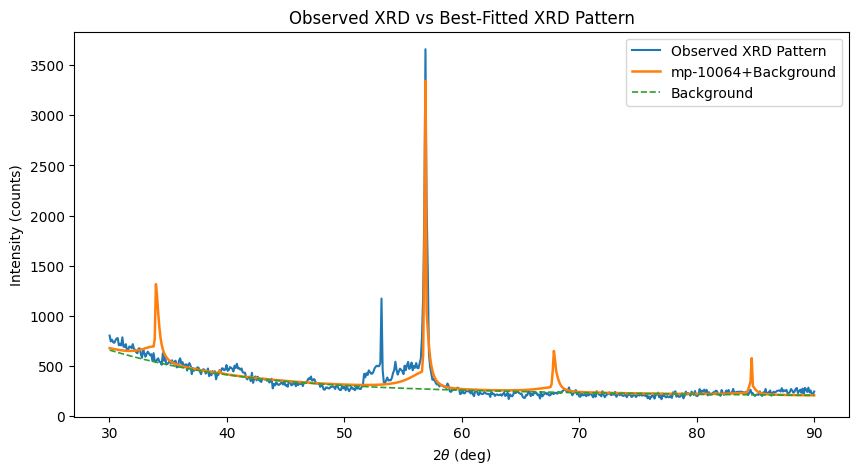

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, label="Observed XRD Pattern", linewidth=1.5)
ax.plot(x, result['best_fit'], label="mp-10064+Background", linewidth=1.8)
ax.plot(x, result['background'], linestyle="--", linewidth=1.2, label="Background")
ax.set_xlabel(r"2$\theta$ (deg)")
ax.set_ylabel("Intensity (counts)")
ax.set_title("Observed XRD vs Best-Fitted XRD Pattern")
ax.legend()
